# Baseline vs. Slerp
This notebook contains the implementation of Slerp method applied on the project's context. It contains also the baseline, needed to make a comparison. The content is the following one:
1. General Setup: data a CLIP download
2. Common functions: functions needed for both slerp and project's baseline.
3. Project's baseline: function a tests of the baseline.
4. Slerp: slerp code and tests.
5. Comparison: comparison between project's baseline and slerp method.

---
## 1. General setup

Import the code dependencies.

In [ ]:
from google.colab import drive
import torch
from pathlib import Path
from torchvision.datasets import CelebA
import numpy as np
from PIL import Image
import torchvision
import torch.nn.functional as F
import json
from torch.utils.data import DataLoader
import shutil
import matplotlib.pyplot as plt

### Dataset setup

Unzip the caleba data into the runtime's local SSD and extract caleba data.

In [ ]:
drive.mount("/content/drive", force_remount=True)

Mounted at /content/drive


In [ ]:
!mkdir /content/datasets

In [ ]:
# unzip the dataset in the runtime's local SSD
!unzip -q /content/drive/MyDrive/deep_learning/data/celeba.zip -d /content/datasets/

In [ ]:
celeba = CelebA(root=Path("/content/datasets"), split="test", download=False)


### CLIP download


Install CLIP and analyze the model.

In [ ]:
!pip install -q huggingface_hub transformers

In [ ]:
from transformers import CLIPModel, CLIPProcessor

model = CLIPModel.from_pretrained("openai/clip-vit-base-patch32")
processor = CLIPProcessor.from_pretrained("openai/clip-vit-base-patch32")

model = model.cuda().eval() # move to the GPU

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:124: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

### Frozen visual features

In [ ]:
!mkdir /content/frozen_data

In [ ]:
!unzip -q /content/drive/MyDrive/deep_learning/data/frozen_data.zip -d /content/datasets/frozen_data

---
## 2. Common Functions

### Text encoding

In [ ]:
def encode_queries(queries):
  """Extrcat text features from queries texts.

  Arg:
    queries: list of queries in the .js file

  Return:
    text_z: list of (normalized) text features
  """
  # tokenize the input queries
  text_t = processor(text=queries, return_tensors="pt", padding=True)

  # input tensors to cuda
  text_ids = text_t['input_ids'].to("cuda")
  # attention mask to cuda
  attention_mask = text_t['attention_mask'].to("cuda")

  # encode the text with CLIP (latent space)
  with torch.no_grad():
      text_z_output = model.get_text_features(
          input_ids=text_ids,
          attention_mask=attention_mask
      )

  text_z = text_z_output.pooler_output # the tensor
  # normalize the features
  text_z = text_z / text_z.norm(dim=-1, keepdim=True)

  return text_z

In [ ]:
def get_annotations(annotations_path):
  """Extract queries and groundtruth annotations from .js file.

  Arg:
    annotations_path: path to the .js file

  Return:
    annotations: list of queries and groundtruth annotations
  """
  with open(annotations_path, "r") as f:
    annotations = json.load(f)

  return annotations

### Latent space arithmetic and model predicitions

All this code is bad, but it is like this to avoid exhausting Colab resources (principally RAM). If we want to use it in the final project (even if I do not thing so because it is the baseline) we need to write it better.

In [ ]:
def cosine_similarity(image_query_z, image_z):
  """Computes cosine similarity between tewo images.

  Arg:
    image_query_z: (normalized) image features modified with the query texts
    image_z: (normalized) image features

  Return:
    cosine similarity between the two images
  """
  return F.cosine_similarity(image_query_z.unsqueeze(1), image_z.unsqueeze(0), dim=-1).cpu()

In [ ]:
def get_predictions(modified_target, k, data_path):
  """Find the predictions based on cosine similarity.

  Arg:
    modified_target: tensor of the target image modified with the query
    k: the cutoff for top-K evaluation (e.g., 1, 5, 10)
    data_path: path where images features are contained

  Return:
    predictions: dictionary of the first k predictions
  """
  images_sim_cos = {}
  for pt_file in data_path.glob("*.pt"):
      tensor = torch.load(pt_file).to("cuda")
      idx = int(pt_file.name.replace(".pt", ""))
      images_sim_cos[idx] = cosine_similarity(modified_target, tensor)

  predictions = sorted(
    images_sim_cos.items(),
    key=lambda x: x[1],
    reverse=True
  )
  predictions = dict(predictions[:k])

  return predictions


### Model evaluation

Function to evaluate (recall and precision) the final model. This function was given by the professor in the project's skeleton.

In [ ]:
def evaluate_retrieval(
    retrieved_indices: list[int],
    ground_truth_indices: list[int],
    k: int
):
    """
    Evaluate the retrieval performance for a single source image.

    Args:
    ----
        retrieved_indices: list of image IDs predicted by the model,
            ordered by similarity (descending).
        ground_truth_indices: list of valid target IDs from the benchmark JSON.
        k: the cutoff for top-K evaluation (e.g., 1, 5, 10).

    Return:
    ------
        A dictionary containing Recall@K and Precision@K.

    """
    # Isolate the top K predictions
    top_k_retrieved = retrieved_indices[:k]

    # Calculate the intersection between predictions and ground truth
    hits = set(top_k_retrieved).intersection(set(ground_truth_indices))
    num_hits = len(hits)

    # Metrics calculations
    # Recall@K (Hit Rate): 1 if at least one match is found, 0 otherwise
    recall_at_k = 1 if num_hits > 0 else 0

    # Precision@K: Fraction of top K predictions that are correct
    precision_at_k = num_hits / k

    return {
        f"Recall@{k}": recall_at_k,
        f"Precision@{k}": precision_at_k
    }

In [ ]:
def plot_targets(v_ref_idx, query, annotations, query_id, k_to_plot=5):
  target_image, _ = celeba[int(v_ref_idx)]

  # Prepare the figure for plotting
  fig, axes = plt.subplots(1, k_to_plot + 1, figsize=(20, 5))

  # Plot the target image
  axes[0].imshow(target_image)
  axes[0].set_title(f'Reference Image: {v_ref_idx} - Query: {query}')
  axes[0].axis('off')

  # Plot the k retrieved images
  for i in range(k_to_plot):
    image, _ = celeba[int(annotations[query_id]["ground_truth"][v_ref_idx][i])]
    axes[i+1].imshow(image)
    axes[i+1].set_title(f'Target Image: {annotations[query_id]["ground_truth"][v_ref_idx][i]}')
    axes[i+1].axis('off')

  plt.tight_layout()
  plt.show()

In [ ]:
def plot_predictions(v_ref_idx, query, predictions, k_to_plot=5):
  target_image, _ = celeba[int(v_ref_idx)]

  # Prepare the figure for plotting
  fig, axes = plt.subplots(1, k_to_plot + 1, figsize=(20, 5))

  # Plot the target image
  axes[0].imshow(target_image)
  axes[0].set_title(f'Reference Image: {v_ref_idx} - Query: {query}')
  axes[0].axis('off')

  predictions_idx = list(predictions.keys())
  # Plot the k retrieved images
  for i, idx in enumerate(predictions_idx[:k_to_plot]):
    image, _ = celeba[int(idx)]
    axes[i+1].imshow(image)
    axes[i+1].set_title(f'Prediction: {idx}')
    axes[i+1].axis('off')

  plt.tight_layout()
  plt.show()

---
## 3. Project's Baseline

### Text encoding

In [ ]:
def get_unsigned_queries(annotations):
  """Creates a list of unsigned queries (ex: +Smiling becomes Smiling)

  Arg:
    annotations: list of queries and groundtruth annotations

  Return:
    queries_unsigned: list of unsigned queries
  """
  queries = [a["query"] for a in annotations]

  queries_unsigned = []
  for query in queries:
    # if a query contains multiple features, divide them
    # and remove sign
    if ',' in query:
      multiple_q = [q.strip() for q in query.split(",")]
      multiple_q = [q[1:] for q in multiple_q]
      queries_unsigned += multiple_q
    else:
      # remove sign (first character)
      queries_unsigned.append(query[1:])

  return list(dict.fromkeys(queries_unsigned))


### Latent space arithmetic

In [ ]:
def modify_target(visual_path, target_idx, texts, query):
  """Apply query to the target image (latent space arithmetic)

  Arg:
    visual_path: path where images features are contained
    target_idx: index of the target image in celeba
    texts: dictionary of unsigned queries and text features
    query: query to be applied

  Return:
    target_tensor: tensor of the target image modified with the query
  """
  # extract visual features of the specific target
  filename = f"{target_idx}.pt"
  file_path = visual_path / filename
  target_tensor = torch.load(file_path, map_location="cpu").to("cuda")


  # perform naive arithmetic operations in the latent space
  multiple_q = [q.strip() for q in query.split(",")]
  for q in multiple_q:
      if '+' in q:
          target_tensor = target_tensor + texts[q[1:]].unsqueeze(0)
      else:
          target_tensor = target_tensor - texts[q[1:]].unsqueeze(0)

  target_tensor = target_tensor / target_tensor.norm(dim=-1, keepdim=True)

  return target_tensor

### Query testing

In [ ]:
# DEBUG
def test_query(query_id, multiple_k, directory, annotations, texts, n_images = None):
  """Test the model with a specific query.

  Arg:
    query_id: index of the query in the .js file
    multiple_k: list containing the cutoffs for top-K evaluation (e.g., 1, 5, 10)
    n_images: number of reference images to test the model
    directory: path where images features are contained
    annotations: contains the queries and groundtruth
    texts: dictionary of unsigned queries and text features
  """
  # get all reference images for the query passed in input
  target_images_ids = list(annotations[query_id]["ground_truth"].keys())

  # if the number of reference images is not specified, explore all the images
  if n_images is None:
    n_images = len(target_images_ids)

  # mean of evaluation metrics for different k
  total_recall = np.zeros(len(multiple_k))
  total_precision = np.zeros(len(multiple_k))

  # for every reference image
  for id in target_images_ids[:n_images]:
    # fusion mechanism
    modified_target = modify_target(
        directory,
        id,
        texts,
        annotations[query_id]["query"]
    )
    # predictions
    predictions = get_predictions(modified_target, max(multiple_k), directory)
    # store first prediction (necessary to analyze plots)
    if id == target_images_ids[0]:
      first_pred = predictions
    # compute metrics with different k
    for i, k in enumerate(multiple_k):
      eval = evaluate_retrieval(
          list(predictions.keys()),
          list(annotations[query_id]["ground_truth"][id]),
          k
      )
      total_recall[i] += eval[f"Recall@{k}"]
      total_precision[i] += eval[f"Precision@{k}"]

  # compute and print average metrics
  average_recall = total_recall / n_images
  average_precision = total_precision / n_images
  print(f"Query {annotations[query_id]["query"]}:")
  for i, k in enumerate(multiple_k):
    print(f"  Average Recall@{k}: {average_recall[i]:.4f}")
    print(f"  Average Precision@{k}: {average_precision[i]:.4f}")

  return first_pred


---
## 3. Slerp

### Text encoding

In [ ]:
def compose_query(query):
  """Method to modify queries before encoding them with CLIP text encoder.

  Arg:
    query: query in the .js file

  Return:
    final_text_input: modified query
  """
  attributes = [a.strip() for a in query.split(",")]
  signs = [a[0] for a in attributes]
  unsigned_attributes = [a[1:] for a in attributes]
  unsigned_attributes = [a.replace("_", " ").lower() for a in unsigned_attributes]

  idx = 0
  final_text_input = ""
  while idx < len(unsigned_attributes):
    match(unsigned_attributes[idx]):
      case "smiling" | "wearing lipstick" | "wearing hat":
        text_sign =  "is " if signs[idx] == "+" else "is not "
      case "male" | "young":
        text_sign =  "" if signs[idx] == "+" else "not "
      case _:
        text_sign =  "with " if signs[idx] == "+" else "without "

    final_text_input += f"{text_sign}{unsigned_attributes[idx]}"

    idx = idx + 1
    if idx < len(unsigned_attributes):
      final_text_input += " and "

  return final_text_input

In [ ]:
# DEBUG: see how queries are modified
modified_queries = [compose_query(a["query"]) for a in annotations]
modified_queries

['is smiling',
 'with eyeglasses',
 'without heavy makeup',
 'male',
 'not young',
 'with blond hair',
 'with mustache',
 'not young',
 'with eyeglasses and is smiling',
 'with black hair and without wavy hair',
 'not male and without mustache',
 'with chubby and not young',
 'is not smiling and with eyeglasses and is wearing hat',
 'is wearing lipstick and without heavy makeup and is smiling']

In [ ]:
def text_arithmetic(texts, query):
  """Apply query to the target image (latent space arithmetic)

  Arg:
    visual_path: path where images features are contained
    target_idx: index of the target image in celeba
    texts: dictionary of unsigned queries and text features
    query: query to be applied

  Return:
    target_tensor: tensor of the target image modified with the query
  """


  # perform naive arithmetic operations in the latent space
  multiple_q = [q.strip() for q in query.split(",")]
  first_q = multiple_q[0]
  target_tensor = torch.zeros_like(texts[first_q[1:]].unsqueeze(0))
  for q in multiple_q:
      if '+' in q:
          target_tensor += texts[q[1:]].unsqueeze(0)
      else:
          target_tensor -= texts[q[1:]].unsqueeze(0)

  target_tensor = target_tensor / target_tensor.norm(dim=-1, keepdim=True)

  return target_tensor

### Fusion Mechanism

In [ ]:
def slerp(visual_path, target_idx, w, alpha):
  """Slerp implementation.

  Arg:
    visual_path: directory path to the frozen visual features
    target_idx: idx of the refrence image
    w: text features of the query
    alpha: hyperparameter of slerp
  """
  # extract visual features of the specific target
  filename = f"{target_idx}.pt"
  file_path = visual_path / filename
  v = torch.load(file_path, map_location="cpu").to("cuda")
  w = w.to("cuda")

  assert v.shape == w.shape, "shapes of v0 and v1 must match"

  v_w_dot = (v * w).sum(-1, keepdim=True)
  v_w_dot = torch.clamp(v_w_dot, -1.0, 1.0)
  theta = torch.acos(v_w_dot)

  # needed to avoid denominator near to 0
  eps = 1e-6

  first_arg = torch.sin((1 - alpha) * theta) / torch.sin(theta + eps)
  second_arg = torch.sin(alpha * theta) / torch.sin(theta + eps)

  v_target = first_arg * v + second_arg * w

  v_target = F.normalize(v_target, dim=-1)

  return v_target

In [ ]:
# DEBUG: first target image for query +Smiling
modified_query = compose_query(annotations[0]["query"])
query_t_features = encode_queries(modified_query)
reference_images_ids = list(annotations[0]["ground_truth"].keys())
directory = Path("/content/datasets/frozen_data")

res = slerp(directory, reference_images_ids[0], query_t_features, 0.5)

### Predictions and evaluation

In [26]:
# DEBUG
def test_query_slerp(query_id, multiple_k, directory, alpha, annotations, n_images = None, texts = None):
  """Test the model with a specific query.

  Arg:
    query_id: index of the query in the .js file
    k: list containing the cutoff for top-K evaluation (e.g., 1, 5, 10)
    n_images: number of reference images to test the model
    directory: path where images features are contained
    annotations: contains the queries and groundtruth
  """
  target_images_ids = list(annotations[query_id]["ground_truth"].keys())

  # if the number of reference images is not specified, explore all the images
  if n_images is None:
    n_images = len(target_images_ids)

  # mean of evaluation metrics for different k
  total_recall = np.zeros(len(multiple_k))
  total_precision = np.zeros(len(multiple_k))

  for id in target_images_ids[:n_images]:
    # modify query before computing the text features with CLIP text encoder
    if texts is None:
      modified_query = compose_query(annotations[query_id]["query"])
      query_t_features = encode_queries(modified_query)
    else: # latent space arithmetic
      query_t_features = text_arithmetic(texts, annotations[query_id]["query"])

    v_target = slerp(directory, id, query_t_features, alpha)
    predictions = get_predictions(v_target, max(multiple_k), directory)

    if id == target_images_ids[0]:
      first_pred = predictions

    for i, k in enumerate(multiple_k):
      eval = evaluate_retrieval(
          list(predictions.keys()),
          list(annotations[query_id]["ground_truth"][id]),
          k
      )
      total_recall[i] += eval[f"Recall@{k}"]
      total_precision[i] += eval[f"Precision@{k}"]

  # compute and print average metrics
  average_recall = total_recall / n_images
  average_precision = total_precision / n_images
  print(f"Query {annotations[query_id]["query"]}:")
  for i, k in enumerate(multiple_k):
    print(f"  Average Recall@{k}: {average_recall[i]:.4f}")
    print(f"  Average Precision@{k}: {average_precision[i]:.4f}")

  return first_pred

---
## 5. Comparison



In [27]:
# DEBUG
directory = Path("/content/datasets/frozen_data")
annotations_path = Path(
    "/content/drive/MyDrive/deep_learning/data/celeba_evaluation.json"
)
annotations = get_annotations(annotations_path)

# BASELINE SETUP
# get queries
queries_unsigned = get_unsigned_queries(annotations)
# obtain text features of the queries
text_features = encode_queries(queries_unsigned)
# store mapping between text features and unsigned queries
texts = dict(zip(queries_unsigned, text_features))

for query_id in range(1, len(annotations)):
  print(f"Baseline results ({annotations[query_id]['query']}):")
  _ = test_query(query_id, [1, 5, 10], directory, annotations, texts, 10)
  print(f"Slerp results ({annotations[query_id]['query']}):")
  _ = test_query_slerp(query_id, [1, 5, 10], directory, 0.85, annotations, 10)
  print(f"Slerp arithmetic results ({annotations[query_id]['query']}):")
  _ = test_query_slerp(query_id, [1, 5, 10], directory, 0.85, annotations, 10, texts)

Baseline results (+Eyeglasses):
Query +Eyeglasses:
  Average Recall@1: 0.0000
  Average Precision@1: 0.0000
  Average Recall@5: 0.1000
  Average Precision@5: 0.0400
  Average Recall@10: 0.2000
  Average Precision@10: 0.0300
Slerp results (+Eyeglasses):
Query +Eyeglasses:
  Average Recall@1: 0.0000
  Average Precision@1: 0.0000
  Average Recall@5: 0.2000
  Average Precision@5: 0.0600
  Average Recall@10: 0.2000
  Average Precision@10: 0.0400
Slerp arithmetic results (+Eyeglasses):
Query +Eyeglasses:
  Average Recall@1: 0.0000
  Average Precision@1: 0.0000
  Average Recall@5: 0.1000
  Average Precision@5: 0.0200
  Average Recall@10: 0.3000
  Average Precision@10: 0.0600
Baseline results (-Heavy_Makeup):
Query -Heavy_Makeup:
  Average Recall@1: 0.0000
  Average Precision@1: 0.0000
  Average Recall@5: 0.1000
  Average Precision@5: 0.0200
  Average Recall@10: 0.1000
  Average Precision@10: 0.0100
Slerp results (-Heavy_Makeup):
Query -Heavy_Makeup:
  Average Recall@1: 0.1000
  Average Precis

KeyboardInterrupt: 

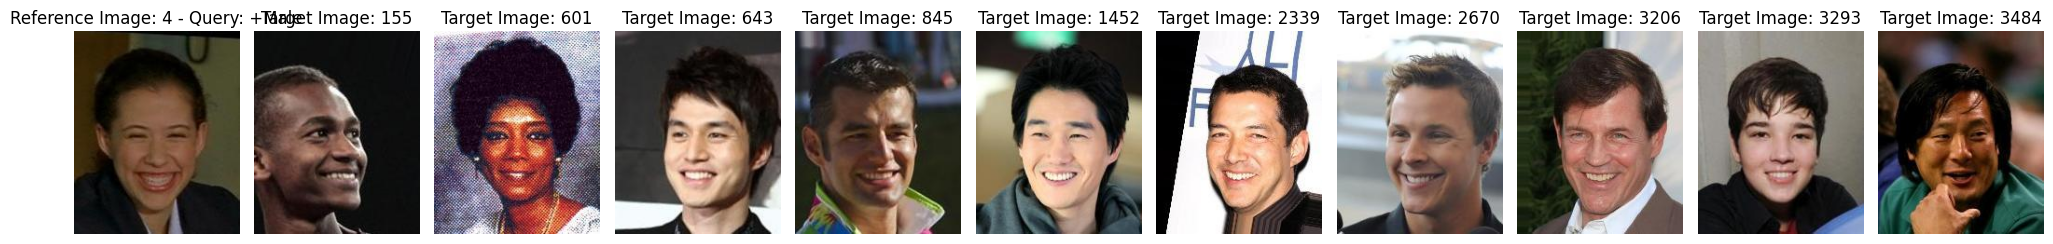

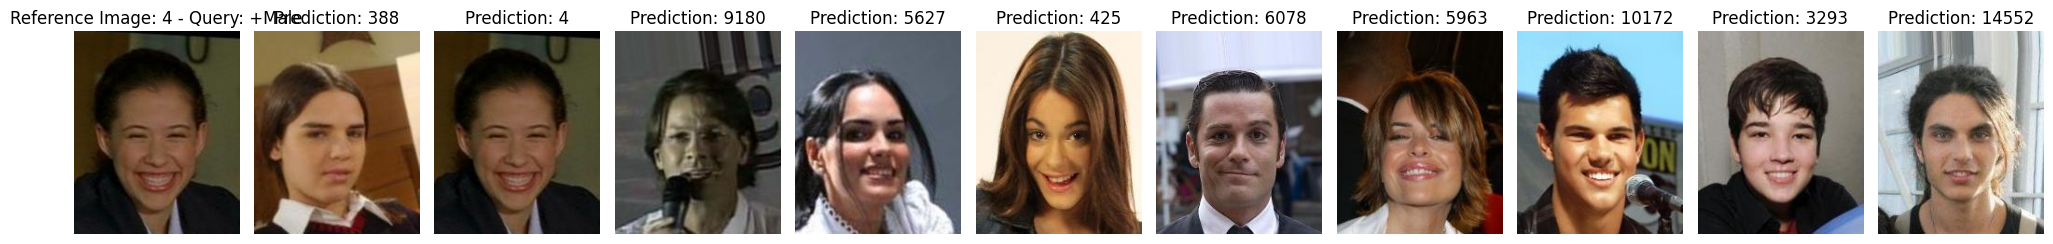

In [ ]:
# DEBUG TEST 4: first 5 images for query -Heavy_Makeup
directory = Path("/content/datasets/frozen_data")
annotations_path = Path(
    "/content/drive/MyDrive/deep_learning/data/celeba_evaluation.json"
)
annotations = get_annotations(annotations_path)

# BASELINE SETUP
queries_unsigned = get_unsigned_queries(annotations)
text_features = encode_queries(queries_unsigned)
texts = dict(zip(queries_unsigned, text_features))

# BASELINE
print("\nBaseline Results +Male:")
first_pred = test_query(3, [1, 5, 10], directory, annotations, texts, 5)

# SLERP
print("Slerp Results +Male:")
first_pred_slerp = test_query_slerp(3, [1, 5, 10], directory, 0.85, annotations, 5)

# PLOTS
target_images_ids = list(annotations[3]["ground_truth"].keys())
query = annotations[3]["query"]
plot_targets(target_images_ids[0], query, annotations, 3, 10)
plot_predictions(target_images_ids[0], query, first_pred, 10)
plot_predictions(target_images_ids[0], query, first_pred_slerp, 10)